# Imports and Setup

In [1]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("final_model")
tokenizer = AutoTokenizer.from_pretrained("final_model")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# !pip install -U transformers==4.40.1 peft==0.10.0 accelerate==0.27.2
!pip install transformers==4.37.2 sentence-transformers==2.5.1 bertopic==0.16.0
# !pip install nltk
plt.style.use('ggplot')
!pip install wordcloud
# import nltk
import re
!pip install textstat
from textstat import textstat
import string
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud
from collections import Counter
from nltk.corpus import stopwords
# !pip install torch
import torch


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Data Loading and Initial Inspection

In [3]:
# Read in data
df = pd.read_csv('archive/Reviews.csv')
print(df.shape)
df = df.head(168454)
print(df.shape)

(568454, 10)
(168454, 10)


In [9]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Clean_Text,Text_Length
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,I have bought several of the Vitality canned d...,262
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Product arrived labeled as Jumbo Salted Peanut...,190
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,This is a confection that has been around a fe...,504
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,If you are looking for the secret ingredient i...,217
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Great taffy at a great price. There was a wide...,137


In [4]:
df.dtypes

Id                        int64
ProductId                   str
UserId                      str
ProfileName                 str
HelpfulnessNumerator      int64
HelpfulnessDenominator    int64
Score                     int64
Time                      int64
Summary                     str
Text                        str
dtype: object

In [5]:
df['Id'] = df['Id'].astype('int32')
df['Score'] = df['Score'].astype('int8') 
df['HelpfulnessNumerator'] = df['HelpfulnessNumerator'].astype('int16')
df['HelpfulnessDenominator'] = df['HelpfulnessDenominator'].astype('int16')
df['Time'] = df['Time'].astype('int32') 
df.dtypes

Id                        int32
ProductId                   str
UserId                      str
ProfileName                 str
HelpfulnessNumerator      int16
HelpfulnessDenominator    int16
Score                      int8
Time                      int32
Summary                     str
Text                        str
dtype: object

In [6]:
import re

def clean_text(text):
    # Convert to string (handle NaN)
    text = str(text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Replaces them with a space to prevent words from running together.
    text = re.sub(r'<br\s*/?>', ' ', text, flags=re.IGNORECASE)
    
    # Remove other general HTML tags (e.g., <b>, <i>, <div>)
    text = re.sub(r'<.*?>', '', text)
    
    # Remove extra whitespaces
    text = ' '.join(text.split())
    
    return text

df['Clean_Text'] = df['Text'].apply(clean_text)

print(f"Null reviews: {df['Text'].isnull().sum()}")

df['Text_Length'] = df['Clean_Text'].str.len()
print(df['Text_Length'].describe())

df_filtered = df[df['Text_Length'] > 10]
print(f"Original size: {len(df)}, Filtered size: {len(df_filtered)}")

df = df_filtered

Null reviews: 0
count    168454.000000
mean        431.743894
std         428.108241
min           0.000000
25%         179.000000
50%         302.000000
75%         525.000000
max       16170.000000
Name: Text_Length, dtype: float64
Original size: 168454, Filtered size: 168450


In [7]:
# Function to extract text features
def extract_text_features(text):
    features = {}
    
    features['word_count'] = len(text.split())
    features['char_count'] = len(text)
    features['sentence_count'] = text.count('.') + text.count('!') + text.count('?')
    
    # Average word length
    words = text.split()
    features['avg_word_length'] = sum(len(word) for word in words) / len(words) if words else 0
    
    # Punctuation counts
    features['exclamation_count'] = text.count('!')
    features['question_count'] = text.count('?')
    features['punctuation_count'] = sum(1 for char in text if char in string.punctuation)
    
    # Capital letters
    features['capital_count'] = sum(1 for char in text if char.isupper())
    features['capital_ratio'] = features['capital_count'] / len(text) if len(text) > 0 else 0
    
    # All caps words (potential shouting)
    features['allcaps_words'] = sum(1 for word in words if word.isupper() and len(word) > 1)
    
    # Readability scores
    try:
        features['flesch_reading_ease'] = textstat.flesch_reading_ease(text)
        features['flesch_kincaid_grade'] = textstat.flesch_kincaid_grade(text)
    except:
        features['flesch_reading_ease'] = 0
        features['flesch_kincaid_grade'] = 0
    
    return features

## Feature Visualization

In [8]:
print("Extracting text features from all reviews...")
# Apply feature extraction
text_features = df['Clean_Text'].apply(extract_text_features)
features_df = pd.DataFrame(text_features.tolist())

# Merge features back to main dataframe
df = pd.concat([df.reset_index(drop=True), features_df], axis=1)

print(f"✓ Added {len(features_df.columns)} text features")
print(f"\nFeatures added: {list(features_df.columns)}")

# Display feature statistics by score
print("\n=== Text Features by Star Rating ===")
feature_cols = ['word_count', 'exclamation_count', 'question_count', 
                'capital_ratio', 'flesch_reading_ease']

for feature in feature_cols:
    print(f"\n{feature.upper()}:")
    print(df.groupby('Score')[feature].mean().round(2))

Extracting text features from all reviews...
✓ Added 12 text features

Features added: ['word_count', 'char_count', 'sentence_count', 'avg_word_length', 'exclamation_count', 'question_count', 'punctuation_count', 'capital_count', 'capital_ratio', 'allcaps_words', 'flesch_reading_ease', 'flesch_kincaid_grade']

=== Text Features by Star Rating ===

WORD_COUNT:
Score
1    87.90
2    90.97
3    98.03
4    93.80
5    73.75
Name: word_count, dtype: float64

EXCLAMATION_COUNT:
Score
1    0.75
2    0.34
3    0.30
4    0.47
5    0.91
Name: exclamation_count, dtype: float64

QUESTION_COUNT:
Score
1    0.21
2    0.15
3    0.13
4    0.09
5    0.07
Name: question_count, dtype: float64

CAPITAL_RATIO:
Score
1    0.04
2    0.03
3    0.03
4    0.03
5    0.03
Name: capital_ratio, dtype: float64

FLESCH_READING_EASE:
Score
1    75.80
2    75.91
3    75.68
4    76.05
5    77.08
Name: flesch_reading_ease, dtype: float64


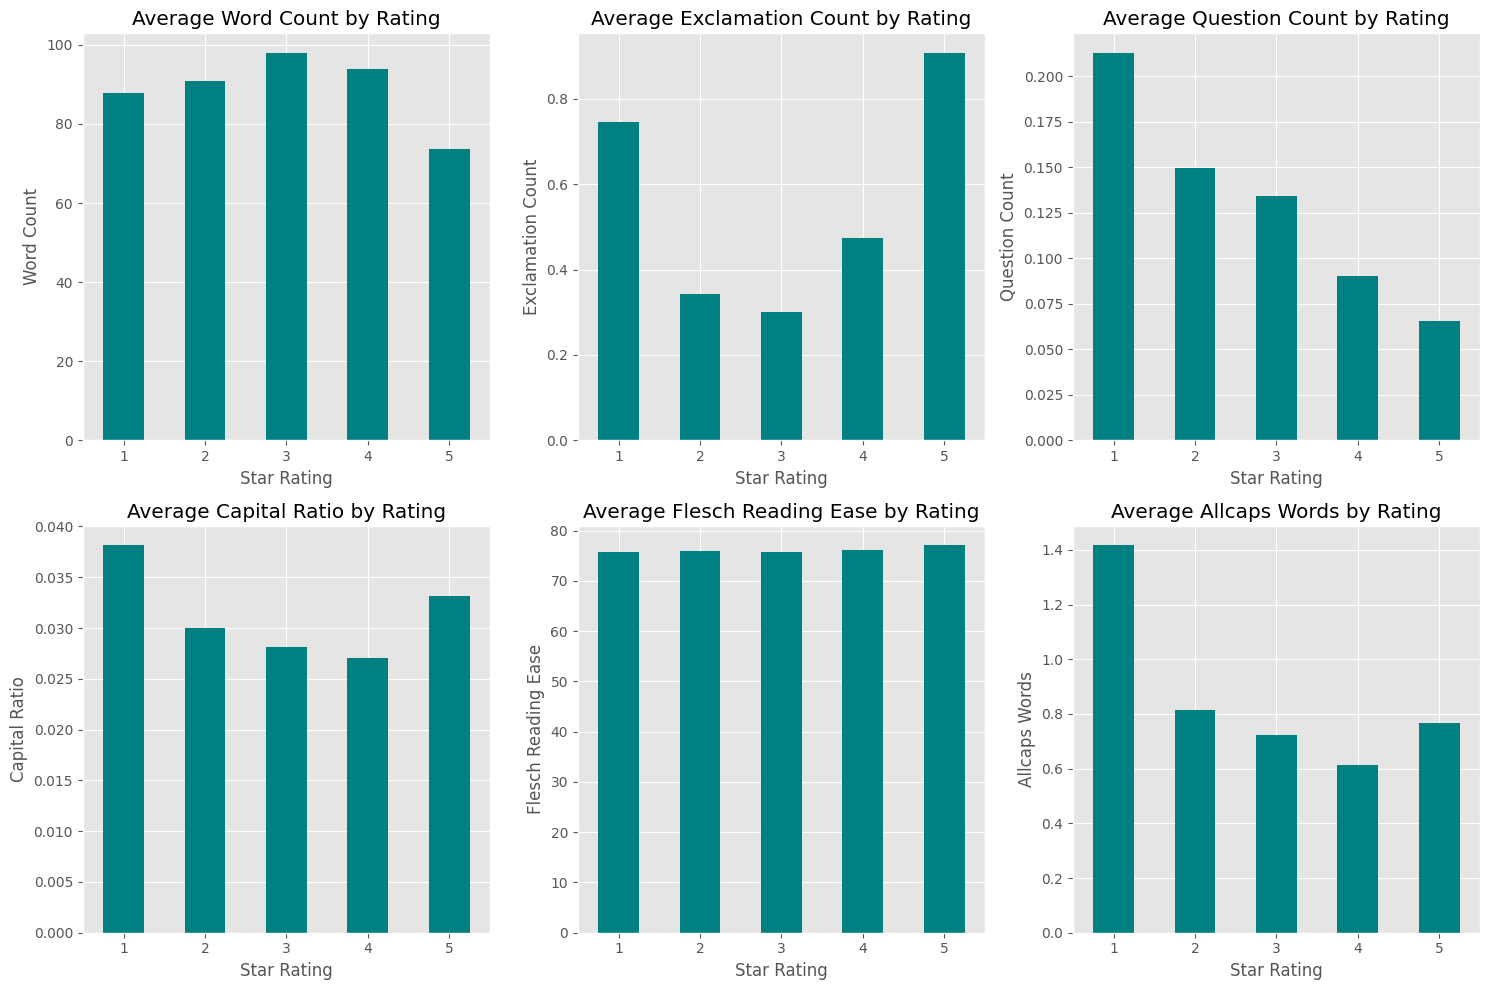


=== Feature Correlation with Score ===


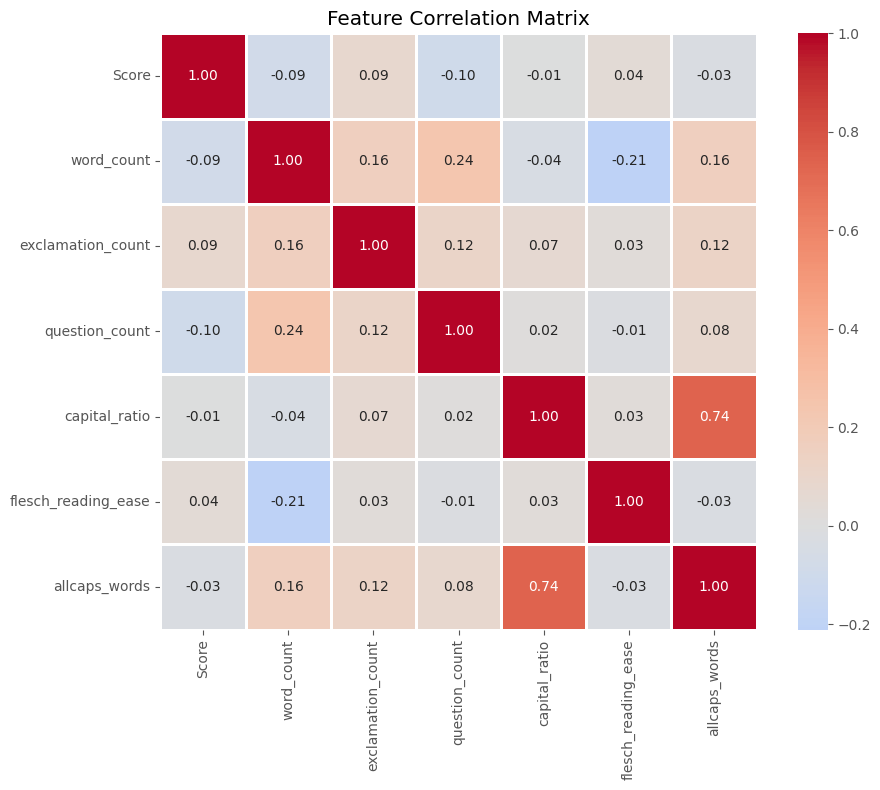

In [9]:


# Visualize key features by score
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

features_to_plot = ['word_count', 'exclamation_count', 'question_count', 
                    'capital_ratio', 'flesch_reading_ease', 'allcaps_words']

for idx, feature in enumerate(features_to_plot):
    df.groupby('Score')[feature].mean().plot(kind='bar', ax=axes[idx], color='teal')
    axes[idx].set_title(f'Average {feature.replace("_", " ").title()} by Rating')
    axes[idx].set_xlabel('Star Rating')
    axes[idx].set_ylabel(feature.replace("_", " ").title())
    axes[idx].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Correlation heatmap between features and score
print("\n=== Feature Correlation with Score ===")
correlation_features = ['Score', 'word_count', 'exclamation_count', 'question_count',
                        'capital_ratio', 'flesch_reading_ease', 'allcaps_words']
correlation_matrix = df[correlation_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [10]:
print("\n=== Class Distribution Analysis ===")
score_counts = df['Score'].value_counts().sort_index()
print(score_counts)
print(f"\nPercentages:")
print((score_counts / len(df) * 100).round(2))

# Create binary sentiment labels
def label_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['Sentiment'] = df['Score'].apply(label_sentiment)
print(f"\n=== Binary Sentiment Distribution ===")
print(df['Sentiment'].value_counts())
print(f"\nPercentages:")
print((df['Sentiment'].value_counts() / len(df) * 100).round(2))

from sklearn.utils import resample

# Separate by sentiment
df_positive = df[df['Sentiment'] == 'positive']
df_neutral = df[df['Sentiment'] == 'neutral']
df_negative = df[df['Sentiment'] == 'negative']

# Find minimum class size
min_size = min(len(df_positive), len(df_neutral), len(df_negative))
print(f"\nMinimum class size: {min_size}")

# Balance to a reasonable size
target_size = min(50000, min_size * 3)


=== Class Distribution Analysis ===
Score
1     15531
2      8954
3     13139
4     24606
5    106220
Name: count, dtype: int64

Percentages:
Score
1     9.22
2     5.32
3     7.80
4    14.61
5    63.06
Name: count, dtype: float64

=== Binary Sentiment Distribution ===
Sentiment
positive    130826
negative     24485
neutral      13139
Name: count, dtype: int64

Percentages:
Sentiment
positive    77.66
negative    14.54
neutral      7.80
Name: count, dtype: float64

Minimum class size: 13139


In [11]:
from sklearn.utils import resample
df_positive_downsampled = resample(df_positive, 
                                   replace=False,
                                   n_samples=target_size,
                                   random_state=42)
df_neutral_downsampled = resample(df_neutral,
                                  replace=False,
                                  n_samples=min(target_size, len(df_neutral)),
                                  random_state=42)
df_negative_downsampled = resample(df_negative,
                                   replace=False,
                                   n_samples=min(target_size, len(df_negative)),
                                   random_state=42)

# Combine balanced dataset
df_balanced = pd.concat([df_positive_downsampled, 
                        df_neutral_downsampled, 
                        df_negative_downsampled])

# Shuffle the dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n=== Balanced Dataset ===")
print(f"Original size: {len(df)}")
print(f"Balanced size: {len(df_balanced)}")
print(f"\nBalanced sentiment distribution:")
print(df_balanced['Sentiment'].value_counts())


=== Balanced Dataset ===
Original size: 168450
Balanced size: 77041

Balanced sentiment distribution:
Sentiment
positive    39417
negative    24485
neutral     13139
Name: count, dtype: int64


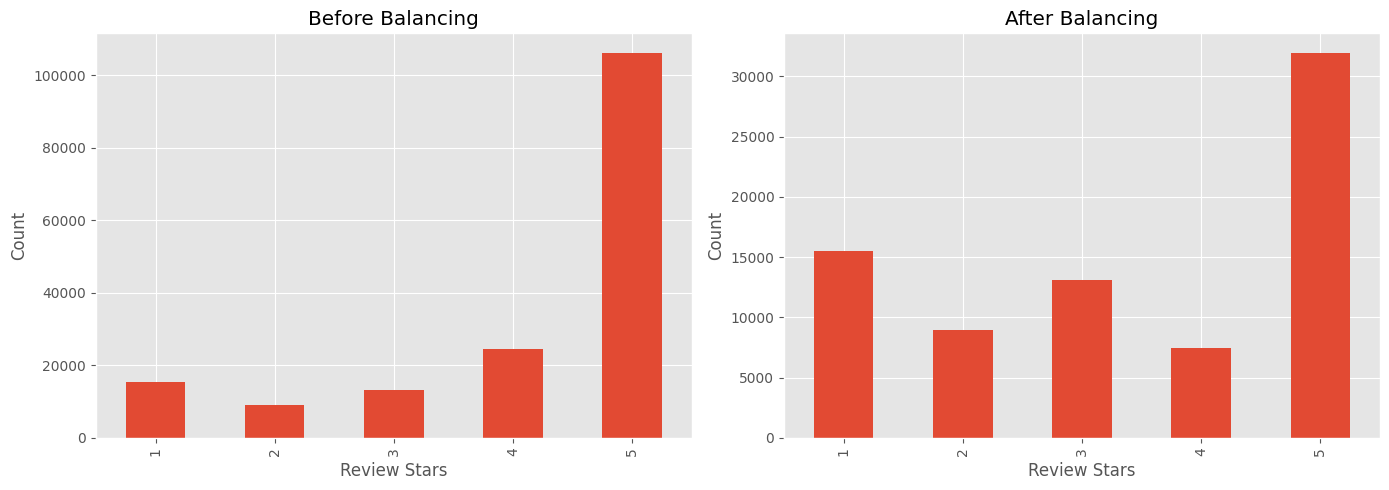

In [12]:
# Visualize before and after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Score'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Before Balancing')
axes[0].set_xlabel('Review Stars')
axes[0].set_ylabel('Count')

df_balanced['Score'].value_counts().sort_index().plot(kind='bar', ax=axes[1], title='After Balancing')
axes[1].set_xlabel('Review Stars')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Use balanced dataset for analysis
df = df_balanced

## Train-Test Split


TRAIN-TEST SPLIT
Total dataset size: 77041
Training set size: 61632 (80.0%)
Test set size: 15409 (20.0%)

Training set distribution:
Sentiment
positive    31533
negative    19588
neutral     10511
Name: count, dtype: int64

Test set distribution:
Sentiment
positive    7884
negative    4897
neutral     2628
Name: count, dtype: int64


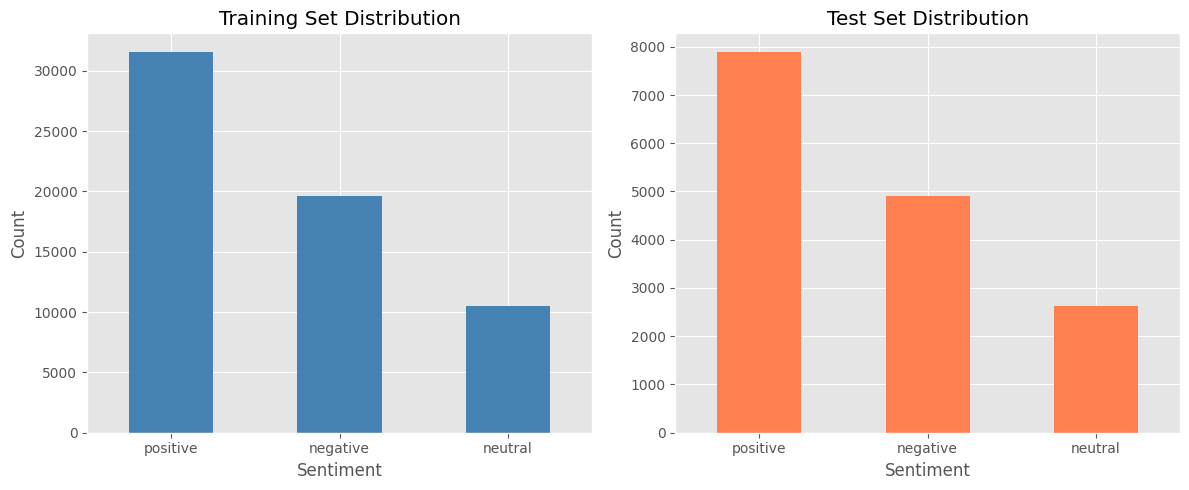


 Using TRAINING SET for model analysis...
  TEST SET will be used for final evaluation only



In [13]:

# Split dataset into train and test sets (80-20 split)
print("\n" + "="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

train_df, test_df = train_test_split(df, 
                                      test_size=0.2, 
                                      random_state=42,
                                      stratify=df['Sentiment'])

print(f"Total dataset size: {len(df)}")
print(f"Training set size: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Test set size: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

print(f"\nTraining set distribution:")
print(train_df['Sentiment'].value_counts())
print(f"\nTest set distribution:")
print(test_df['Sentiment'].value_counts())

# Visualize split
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

train_df['Sentiment'].value_counts().plot(kind='bar', ax=axes[0], title='Training Set Distribution', color='steelblue')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

test_df['Sentiment'].value_counts().plot(kind='bar', ax=axes[1], title='Test Set Distribution', color='coral')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Use training set for the initial analysis and model fitting
# Keep test set completely separate until final evaluation
print("\n Using TRAINING SET for model analysis...")
print("  TEST SET will be used for final evaluation only\n")

## RoBERTa Model and Tokenizer Initialization

In [14]:
from transformers import RobertaTokenizerFast, AutoModelForSequenceClassification, AutoConfig 
import warnings
# Use warnings to suppress non-fatal Hugging Face logging
warnings.filterwarnings("ignore", category=FutureWarning)

# 1. Define the model identifier
MODEL = "cardiffnlp/twitter-roberta-base-sentiment"

print(f"Attempting to load {MODEL}...")

try:
    # --- 1. Load Configuration First (CORRECT) ---
    config = AutoConfig.from_pretrained(
        MODEL,
        num_labels=3, 
        trust_remote_code=False
    )
    print("✅ Configuration loaded.")

    # --- 2. Load the SPECIFIC Tokenizer ---
    tokenizer = RobertaTokenizerFast.from_pretrained(
        MODEL,
        trust_remote_code=False,
        use_fast=True
    )
    print("✅ Tokenizer loaded successfully!")
    
    # --- 3. Load the AUTO Model (CRITICAL FIX) ---
    # THIS MUST BE AutoModelForSequenceClassification, as this is the class that IS imported.
    model = AutoModelForSequenceClassification.from_pretrained( 
        MODEL,
        config=config, # Pass the controlled config object
        trust_remote_code=False,
    )
    print("✅ Model loaded successfully and configured for 3-class fine-tuning!")

except Exception as e:
    print(f"❌ A CRITICAL, UNRECOVERABLE ERROR occurred: {e}")

Attempting to load cardiffnlp/twitter-roberta-base-sentiment...
✅ Configuration loaded.
✅ Tokenizer loaded successfully!
✅ Model loaded successfully and configured for 3-class fine-tuning!


## Using Dataset for Fine-Tuning

In [14]:
from torch.utils.data import Dataset # <--- This is the fix
import torch
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]
        
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create label mapping
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
train_df['label_id'] = train_df['Sentiment'].map(label_map)
test_df['label_id'] = test_df['Sentiment'].map(label_map)

# Create datasets
train_dataset = SentimentDataset(
    train_df['Clean_Text'],
    train_df['label_id'],
    tokenizer
)

test_dataset = SentimentDataset(
    test_df['Clean_Text'],
    test_df['label_id'],
    tokenizer
)

print(f" Training samples: {len(train_dataset)}")
print(f" Test samples: {len(test_dataset)}")

 Training samples: 61632
 Test samples: 15409


# RoBERTa Fine-Tuning Execution 

In [ ]:
from transformers import TrainerCallback
from transformers import TrainingArguments
from transformers import AutoModelForSequenceClassification
from transformers import EarlyStoppingCallback
from transformers import Trainer
# Core & Utility
import torch
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Metrics & Evaluation
from sklearn.metrics import accuracy_score, f1_score

# Hugging Face Transformers
from transformers import (
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    TrainerCallback,
    EarlyStoppingCallback
)

# --- METRICS FUNCTION ---
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    # Use average='macro' or 'micro' if classes are balanced/unbalanced. 'weighted' is good general practice.
    f1 = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'f1': f1}

# --- CUSTOM CALLBACK  ---
class ProgressCallback(TrainerCallback):
    def on_epoch_begin(self, args, state, control, **kwargs):
        # We can disable the default tqdm to rely more on this printout if needed
        print(f"\n📍 Starting Epoch {state.epoch + 1}/{args.num_train_epochs}")
    
    def on_epoch_end(self, args, state, control, **kwargs):
        print(f"✅ Completed Epoch {state.epoch + 1}/{args.num_train_epochs}")
    
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and state.global_step % args.logging_steps == 0:
            # Print only key metrics when available
            loss = logs.get('loss')
            eval_acc = logs.get('eval_accuracy')
            if loss:
                print(f"    Step {state.global_step}: Loss={loss:.4f}", end="")
            if eval_acc:
                print(f" | Eval Accuracy={eval_acc:.4f}", end="")
            print()


# --- OPTIMIZED TRAINING ARGUMENTS ---
training_args = TrainingArguments(
    output_dir='./results_roberta_tuned',
    num_train_epochs=5, 
    per_device_train_batch_size=16, 
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=2,
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,
    # 2. OPTIMIZATION: Fine-tune learning rate and scheduler
    learning_rate=2e-5,  
    warmup_ratio=0.1,
    label_smoothing_factor=0.1,
    weight_decay=0.02,
    
    
    save_strategy="epoch",
    save_total_limit=2,  
    save_steps=100,
    # 4. EVALUATION & LOGGING
    logging_dir='./logs_improved',
    logging_steps=50,
    evaluation_strategy="epoch",
    eval_steps=100,
    metric_for_best_model="accuracy",
    load_best_model_at_end=True,
    greater_is_better=True,
    # 5. HARDWARE OPTIMIZATION
    fp16=torch.cuda.is_available(),
    
    # 6. REPORTING
    disable_tqdm=False, 
    report_to="none",
)


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL,
    num_labels=3,
    hidden_dropout_prob=0.2,
    attention_probs_dropout_prob=0.2,
)
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=1, 
    early_stopping_threshold=0.0001 
)
# --- TRAINER CREATION ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset, 
    eval_dataset=test_dataset,   
    compute_metrics=compute_metrics,
    callbacks=[ProgressCallback(), early_stopping_callback],
)

print("🚀 Starting fine-tuning with optimized parameters...")
print(f"📊 Training samples: {len(train_dataset)}")
print(f"🗂️ Batches per epoch: {len(train_dataset)//training_args.per_device_train_batch_size}")
print(f"💡 Learning Rate: {training_args.learning_rate}")
print(f"💾 Saving Checkpoints: {training_args.save_total_limit} (Best Model Only)\n")

trainer.train()
print("\n✅ Fine-tuning complete!")

In [ ]:
trainer.save_model("/kaggle/working/final_model")
tokenizer.save_pretrained("/kaggle/working/final_model")

In [15]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

model = AutoModelForSequenceClassification.from_pretrained("final_model")
tokenizer = AutoTokenizer.from_pretrained("final_model")

model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    probs = F.softmax(outputs.logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()

    labels = ['negative', 'neutral', 'positive']
    
    return {
        "label": labels[pred],
        "confidence": probs[0][pred].item()
    }


print(predict("This product is amazing!"))
print(predict("Terrible experience, very bad"))

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


{'label': 'positive', 'confidence': 0.9515528082847595}
{'label': 'negative', 'confidence': 0.9556746482849121}


In [25]:
print(predict("The pizza was delicious but the delivery took two hours!"))

{'label': 'positive', 'confidence': 0.42700251936912537}


Đang tải trọng số từ: final_model...
Thiết bị đang dùng: CUDA

Đang chạy dự đoán trên tập test bằng model đã lưu...


Đang đánh giá: 100%|██████████| 964/964 [07:11<00:00,  2.23it/s]



=== ĐÁNH GIÁ MÔ HÌNH (SỬ DỤNG FINAL_MODEL) ===
Accuracy: 0.8692
F1 Score (Weighted): 0.8665
Test Loss: 0.3534


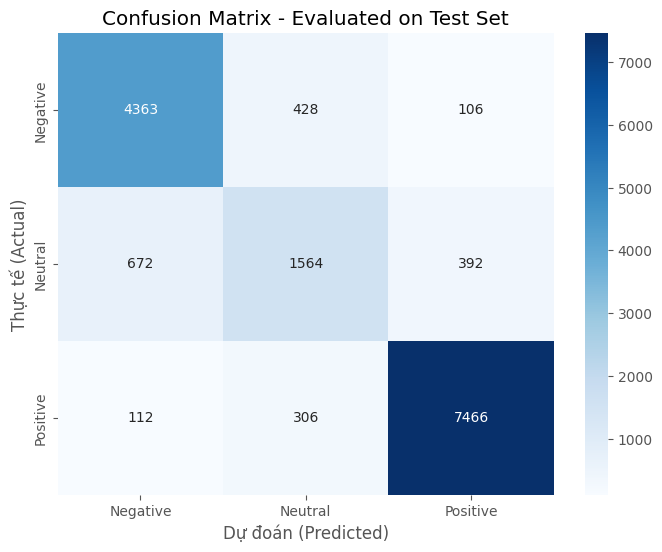


=== CHI TIẾT PHÂN LOẠI ===
              precision    recall  f1-score   support

    Negative       0.85      0.89      0.87      4897
     Neutral       0.68      0.60      0.63      2628
    Positive       0.94      0.95      0.94      7884

    accuracy                           0.87     15409
   macro avg       0.82      0.81      0.82     15409
weighted avg       0.87      0.87      0.87     15409



In [17]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm 

MODEL_PATH = "final_model" 
print(f"Đang tải trọng số từ: {MODEL_PATH}...")

model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiết bị đang dùng: {device.type.upper()}")
model.to(device)
model.eval() 

test_loader = DataLoader(test_dataset, batch_size=16)

all_preds = []
all_labels = []
total_loss = 0

print("\nĐang chạy dự đoán trên tập test bằng model đã lưu...")

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Đang đánh giá"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
 
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        
        total_loss += outputs.loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

avg_loss = total_loss / len(test_loader)
accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"\n=== ĐÁNH GIÁ MÔ HÌNH (SỬ DỤNG FINAL_MODEL) ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (Weighted): {f1:.4f}")
print(f"Test Loss: {avg_loss:.4f}")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = ['Negative', 'Neutral', 'Positive']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Evaluated on Test Set')
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.show()

print("\n=== CHI TIẾT PHÂN LOẠI ===")
print(classification_report(all_labels, all_preds, target_names=class_names))

In [16]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

topic_model = BERTopic.load("my_bertopic_model", embedding_model=embedding_model)

test_reviews = [
    "The food was amazing, very delicious!", 
    "Service was very slow and the waiter was rude."
]

new_topics, new_probs = topic_model.transform(test_reviews)

for i, sentence in enumerate(test_reviews):
    topic_id = new_topics[i]
    print(f"\n--- Câu review: '{sentence}' ---")
    print(f" Được phân vào Topic ID: {topic_id}")
    
    if topic_id != -1:
        print("Các từ khóa chính của Topic này:")
        print(topic_model.get_topic(topic_id)) 
    else:
        print("Mô hình đánh giá đây là câu nhiễu (Outlier), không thuộc chủ đề cụ thể nào.")

print("\nDanh sách tổng hợp ID chủ đề của các câu:", new_topics)

2026-04-01 14:53:00,619 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model.If you want to also load in an embedding model, make sure to useBERTopic.load(my_model, embedding_model=my_embedding_model).


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-04-01 14:53:00,766 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.



--- Câu review: 'The food was amazing, very delicious!' ---
 Được phân vào Topic ID: 125
Các từ khóa chính của Topic này:
[['snack', 0.030751957507143608], ['guite', 0.012117031239174871], ['vegetarians', 0.010252761880582264], ['snacks', 0.010237071997501396], ['sponge', 0.010196905022928015], ['quick', 0.010162646990173675], ['meal', 0.00962865777061139], ['toast', 0.009053076167444283], ['bhuja', 0.008541612201655478], ['hangin', 0.008541612201655478]]

--- Câu review: 'Service was very slow and the waiter was rude.' ---
 Được phân vào Topic ID: 705
Các từ khóa chính của Topic này:
[['email', 0.03369677010099532], ['supervisor', 0.0232524914922364], ['straws', 0.022262632283542222], ['phone', 0.013597084484724518], ['dealt', 0.01337685220693988], ['canceled', 0.012985677611467732], ['lizzies', 0.012882431517250884], ['service', 0.012697324367162264], ['order', 0.012685984716125007], ['upgraded', 0.01233469267685823]]

Danh sách tổng hợp ID chủ đề của các câu: [125 705]


In [17]:
def analyze_full(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    
    probs = F.softmax(outputs.logits, dim=1)
    pred_idx = torch.argmax(probs, dim=1).item()
    
    sentiment_labels = ['negative', 'neutral', 'positive']
    sentiment = sentiment_labels[pred_idx]
    confidence = probs[0][pred_idx].item()

    topics, _ = topic_model.transform([text])
    topic_id = topics[0]
    
    if topic_id != -1:
        keywords = topic_model.get_topic(topic_id)
        keywords_list = [word for word, score in keywords]
    else:
        keywords_list = "Nhiễu / Không xác định"

    return {
        "text": text,
        "sentiment": sentiment,
        "confidence": f"{confidence:.2%}",
        "topic_id": topic_id,
        "topic_keywords": keywords_list
    }

input_text = "The pizza was delicious but the delivery took two hours!"
result = analyze_full(input_text)

print("-" * 30)
print(f"REVIEW: {result['text']}")
print(f"SENTIMENT: {result['sentiment']} ({result['confidence']})")
print(f"TOPIC ID: {result['topic_id']}")
print(f"KEYWORDS: {result['topic_keywords']}")
print("-" * 30)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-04-01 14:53:00,890 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


------------------------------
REVIEW: The pizza was delicious but the delivery took two hours!
SENTIMENT: positive (42.70%)
TOPIC ID: 329
KEYWORDS: ['pizza', 'crust', 'dough', 'crusts', 'chebe', 'toppings', 'mushrooms', 'gluten', 'shit', 'pan']
------------------------------


In [22]:
!pip install nbformat ipywidgets

  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached fastjsonschema-2.21.2-py3-none-any.whl.metadata (2.3 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached rpds_py-0.30.0-cp312-cp312-win_amd64.whl.metadata (4.2 kB)
Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached fastjsonschema-2.21.2-py3-none-any.whl (24 kB)
Using cached jsonschema-4.26.0-py3-none-any.whl (90 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
topic_model.visualize_barchart(top_n_topics=10)